# Demo F: vLLM Serving Throughput & Caching Demo

## Overview
This is a **serving-throughput demo**, not a pure apples-to-apples kernel-level hardware benchmark. 
Our goal is to demonstrate the massive architectural advantages of **Continuous Batching** and **Prefix Caching** in a server environment.
- **HuggingFace Baseline**: Runs natively and sequentially (Batch Size = 1) to simulate naive local inference.
- **vLLM Engine**: Runs highly concurrently (Batch Size = 10) to simulate a real-world serving environment.


## 1. Setup & Utilities

In [1]:
import subprocess, sys
# Ensure dependencies are installed
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--break-system-packages', 'openai', 'transformers', 'accelerate'])

import torch, time, requests, re, threading, gc
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from openai import OpenAI
from concurrent.futures import ThreadPoolExecutor, as_completed
from transformers import AutoTokenizer, AutoModelForCausalLM, LogitsProcessorList, LogitsProcessor

# ─── Config ───
MODEL = 'mistralai/Mistral-7B-v0.1'
PORT = 8000
VLLM_URL = f'http://localhost:{PORT}'
BASE_URL = f'{VLLM_URL}/v1'
N_REQUESTS = 10
N_TOKENS = 50

client = OpenAI(base_url=BASE_URL, api_key='unused')

print('Loading Tokenizer for precise token counting...')
hf_tok = AutoTokenizer.from_pretrained(MODEL)
hf_tok.pad_token_id = hf_tok.eos_token_id

# ─── Generate Long Shared Prefix ───
# We create a large shared system prompt to effectively stress test Prefix Caching.
with open(__file__, 'r') if '__file__' in locals() else open('demo_f_vllm.ipynb', 'r') as f:
    text_content = "This is a system prompt meant to fill the context window. " * 200
SHARED_PREFIX = text_content[:8000] # ~1500-2000 tokens of shared context

QUESTIONS = [
    'Explain the concept of attention mechanisms in transformers.',
    'What are the key differences between CPU and GPU architectures?',
    'Describe how PagedAttention works in vLLM.',
    'What is the roofline model for GPU performance analysis?',
    'Explain continuous batching in LLM serving systems.',
    'How does speculative decoding accelerate inference?',
    'What are the tradeoffs of KV cache quantization?',
    'Describe the prefill vs decode phases of LLM inference.',
    'How do mixture of experts models reduce compute costs?',
    'What is tensor parallelism and when should you use it?',
]

PROMPTS = [f"{SHARED_PREFIX}\n\nQuestion: {q}\nAnswer:" for q in QUESTIONS]
print(f"Generated {len(PROMPTS)} prompts. Shared prefix is {len(hf_tok.encode(SHARED_PREFIX))} tokens long.")


Loading Tokenizer for precise token counting...


Generated 10 prompts. Shared prefix is 1656 tokens long.


## 2. Utility Functions

In [2]:
def check_server():
    try:
        r = requests.get(f'{VLLM_URL}/health', timeout=3)
        r.raise_for_status()
        print(f'vLLM server running.')
        return True
    except:
        print('vLLM server NOT running.')
        return False

def warmup_server(n=5):
    for i in range(n):
        r = requests.post(f'{BASE_URL}/completions',
            json={'model': MODEL, 'prompt': f'Warmup {i}', 'max_tokens': 20})
        r.raise_for_status()
    print(f'Warmup done ({n} requests).')

def get_vllm_metrics():
    r = requests.get(f'{VLLM_URL}/metrics')
    r.raise_for_status()
    metrics = {}
    for line in r.text.split('\n'):
        if line and not line.startswith('#'):
            parts = line.split()
            if len(parts) >= 2:
                try: metrics[parts[0]] = float(parts[-1])
                except ValueError: pass
    return metrics

def benchmark_full(prompts, max_tokens=50, n_workers=10, label=''):
    def single_request(prompt):
        t0 = time.perf_counter()
        first_token_time = None
        last_token_time = None
        
        stream = client.completions.create(
            model=MODEL, prompt=prompt, max_tokens=max_tokens,
            temperature=0, stream=True, stream_options={"include_usage": True}
        )
        
        usage = None
        for chunk in stream:
            now = time.perf_counter()
            if first_token_time is None and len(chunk.choices) > 0 and chunk.choices[0].text:
                first_token_time = now
            last_token_time = now
            if getattr(chunk, 'usage', None) is not None:
                usage = chunk.usage
                
        tokens = usage.completion_tokens if usage else 0
        
        ttft = (first_token_time - t0) if first_token_time else 0
        if tokens > 1 and first_token_time and last_token_time:
            itl = (last_token_time - first_token_time) / (tokens - 1)
        else:
            itl = 0
        return {'ttft': ttft, 'itl': itl, 'tokens': tokens}

    t_wall = time.perf_counter()
    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        futures = [pool.submit(single_request, p) for p in prompts]
        req_results = [f.result() for f in tqdm(as_completed(futures), total=len(prompts), desc=label)]
    wall_time = time.perf_counter() - t_wall

    total_tokens = sum(r['tokens'] for r in req_results)
    throughput = total_tokens / wall_time
    avg_ttft = np.mean([r['ttft'] for r in req_results])
    avg_itl = np.mean([r['itl'] for r in req_results])

    print(f'  [{label}] {throughput:.0f} tok/s | TTFT: {avg_ttft*1000:.0f}ms | ITL: {avg_itl*1000:.1f}ms')
    return {'throughput': throughput, 'ttft': avg_ttft, 'itl': avg_itl,
            'wall_time': wall_time, 'total_tokens': total_tokens}

def measure_kv_vs_users(user_counts=[1, 5, 10, 15, 20], max_tokens=1000):
    kv_data = []
    for n in tqdm(user_counts, desc='KV vs users'):
        prompts_kv = [f'Write a very detailed long essay about topic {i}. Include many examples:' for i in range(n)]
        peak = 0.0
        thread_exc = None
        def send():
            nonlocal thread_exc
            try:
                with ThreadPoolExecutor(max_workers=n) as pool:
                    futs = [pool.submit(requests.post, f'{BASE_URL}/completions',
                        json={'model': MODEL, 'prompt': p, 'max_tokens': max_tokens, 'temperature': 0.7}
                    ) for p in prompts_kv]
                    for f in futs:
                        f.result().raise_for_status()
            except Exception as e:
                thread_exc = e

        t = threading.Thread(target=send)
        t.start()
        time.sleep(0.3)
        for _ in range(20):
            m = get_vllm_metrics()
            for k, v in m.items():
                if 'kv_cache_usage_perc' in k:
                    peak = max(peak, v * 100)
            time.sleep(0.5)
        t.join()
        if thread_exc:
            raise RuntimeError(f"Request failed: {thread_exc}")
        kv_data.append((n, peak))
        print(f'  {n:>3} users -> {peak:.1f}% KV')
    return kv_data

def measure_kv_vs_context(context_lengths=[256, 512, 1024, 2048, 2500], n_users=5, max_tokens=500):
    kv_data = []
    for ctx_len in tqdm(context_lengths, desc='KV vs context'):
        # Generate exactly ctx_len tokens safely
        prompt_base = ('The quick brown fox jumps over the lazy dog. ' * (ctx_len // 5 + 5))
        prompt = hf_tok.decode(hf_tok.encode(prompt_base)[:ctx_len])
        prompts_ctx = [prompt + f' Question {i}: explain.' for i in range(n_users)]
        peak_kv = 0.0
        thread_exc = None
        def send():
            nonlocal thread_exc
            try:
                with ThreadPoolExecutor(max_workers=n_users) as pool:
                    futs = [pool.submit(requests.post, f'{BASE_URL}/completions',
                        json={'model': MODEL, 'prompt': p, 'max_tokens': max_tokens, 'temperature': 0}
                    ) for p in prompts_ctx]
                    for f in futs:
                        f.result().raise_for_status()
            except Exception as e:
                thread_exc = e

        t = threading.Thread(target=send)
        t.start()
        time.sleep(0.5)
        for _ in range(10):
            m = get_vllm_metrics()
            for k, v in m.items():
                if 'kv_cache_usage_perc' in k:
                    peak_kv = max(peak_kv, v * 100)
            time.sleep(0.3)
        t.join()
        if thread_exc:
            raise RuntimeError(f"Request failed: {thread_exc}")
        kv_data.append((ctx_len, peak_kv))
        print(f'  {ctx_len:>5} tokens -> {peak_kv:.1f}% KV')
    return kv_data

def plot_running_comparison():
    valid = {k: v for k, v in all_results.items() if v is not None}
    if not valid: return
    configs = list(valid.keys())
    n_configs = len(configs)
    
    # Very distinct, high-contrast colors suitable for presentations
    bar_colors = ['#1e3a8a', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6'][:n_configs]
    
    has_kv = any(valid[c].get('kv_users') or valid[c].get('kv_context') for c in configs)
    n_cols = 5 if has_kv else 3
    fig, axes = plt.subplots(1, n_cols, figsize=(6*n_cols, 6))
    axes = [axes]
    
    def style_ax(ax, title, ylabel, values, configs, is_lower_better=False):
        x = np.arange(len(configs))
        bars = ax.bar(x, values, color=bar_colors[:len(configs)], edgecolor='#0f172a', linewidth=2, width=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(configs, rotation=25, ha='right', fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
        ax.set_title(title, fontsize=16, fontweight='heavy', pad=15)
        ax.grid(axis='y', alpha=0.4, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_axisbelow(True)
        
        # Add high-contrast value annotations
        for bar, val in zip(bars, values):
            label = f'{val:.0f}' if val >= 10 else f'{val:.1f}'
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(values)*0.02),
                   label, ha='center', fontsize=13, fontweight='heavy', color='#0f172a')
                   
        # Speedup multiplier over baseline (index 0)
        if len(values) > 1 and values[0] > 0:
            for i in range(1, len(values)):
                ratio = values[0]/values[i] if is_lower_better else values[i]/values[0]
                if ratio > 1.2:
                    ax.text(i, values[i] * 0.5, f'{ratio:.1f}x', ha='center', va='center', 
                            fontsize=16, color='white', fontweight='black',
                            bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2', edgecolor='none'))
    
    tps = [valid[c]['throughput'] for c in configs]
    style_ax(axes[0][0], 'Throughput', 'Tokens / Second', tps, configs)
    
    ttfts = [valid[c]['ttft'] * 1000 for c in configs]
    style_ax(axes[0][1], 'Time To First Token (TTFT)', 'Milliseconds', ttfts, configs, is_lower_better=True)
    
    itls = [valid[c]['itl'] * 1000 for c in configs]
    style_ax(axes[0][2], 'Inter-Token Latency (ITL)', 'Milliseconds', itls, configs, is_lower_better=True)
    
    if has_kv and n_cols == 5:
        ax = axes[0][3]
        for i, c in enumerate(configs):
            kv = valid[c].get('kv_users')
            if kv:
                ax.plot([x[0] for x in kv], [x[1] for x in kv], 'D-', color=bar_colors[i], markeredgecolor='black', linewidth=3, markersize=9, label=c)
        ax.set_xlabel('Concurrent Users', fontsize=14, fontweight='bold')
        ax.set_ylabel('KV Cache Usage (%)', fontsize=14, fontweight='bold')
        ax.set_title('KV vs Users', fontsize=16, fontweight='heavy', pad=15)
        ax.grid(alpha=0.4, linestyle='--')
        ax.legend(fontsize=11)
        ax.set_ylim(bottom=0)

        ax = axes[0][4]
        for i, c in enumerate(configs):
            kv = valid[c].get('kv_context')
            if kv:
                ax.plot([x[0] for x in kv], [x[1] for x in kv], 's-', color=bar_colors[i], markeredgecolor='black', linewidth=3, markersize=9, label=c)
        ax.set_xlabel('Context Length (tokens)', fontsize=14, fontweight='bold')
        ax.set_ylabel('KV Cache Usage (%)', fontsize=14, fontweight='bold')
        ax.set_title('KV vs Context (max=3500)', fontsize=16, fontweight='heavy', pad=15)
        ax.grid(alpha=0.4, linestyle='--')
        ax.legend(fontsize=11)
        ax.set_ylim(bottom=0)

    plt.tight_layout(pad=3.0)
    plt.show()

all_results = {}
print('Setup complete.')


Setup complete.


## 3. HuggingFace Baseline
**Methodology Note:** We use a custom `LogitsProcessor` to accurately capture the exact moment the very first token is generated by the model. 
*Note:* We evaluate HF sequentially (batch size 1) vs vLLM concurrently (batch size 10). This demonstrates the power of continuous batching in a server context vs naive local inference.

In [3]:
print('Loading Mistral-7B natively...')
hf_model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=torch.float16, device_map='auto')

# Warmup
for i in range(3):
    w = hf_tok(f'Warmup call {i}', return_tensors='pt').input_ids.to('cuda')
    _ = hf_model.generate(w, max_new_tokens=5, pad_token_id=hf_tok.eos_token_id)
torch.cuda.synchronize()

class TimeFirstTokenProcessor(LogitsProcessor):
    def __init__(self):
        self.t_first = None
    def __call__(self, input_ids, scores):
        if self.t_first is None:
            torch.cuda.synchronize()
            self.t_first = time.perf_counter()
        return scores

hf_ttfts = []
hf_itls = []
hf_total_tokens = 0
torch.cuda.synchronize()
hf_start = time.perf_counter()

for prompt in tqdm(PROMPTS, desc='HF throughput/TTFT/ITL'):
    ids = hf_tok(prompt, return_tensors='pt').input_ids.to('cuda')
    t_first_proc = TimeFirstTokenProcessor()
    processors = LogitsProcessorList([t_first_proc])
    
    t0 = time.perf_counter()
    with torch.no_grad():
        out = hf_model.generate(ids, max_new_tokens=N_TOKENS, pad_token_id=hf_tok.eos_token_id, logits_processor=processors)
    torch.cuda.synchronize()
    t1 = time.perf_counter()
    
    # Calculate exact generated tokens using tokenizer output shapes
    gen_tokens = out.shape[1] - ids.shape[1]
    total_time = t1 - t0
    
    ttft = t_first_proc.t_first - t0 if t_first_proc.t_first else total_time
    hf_ttfts.append(ttft)
    if gen_tokens > 1:
        hf_itls.append((total_time - ttft) / (gen_tokens - 1))
    else:
        hf_itls.append(0)
    hf_total_tokens += gen_tokens

hf_wall = time.perf_counter() - hf_start
hf_throughput = hf_total_tokens / hf_wall
print(f'Throughput: {hf_throughput:.1f} tok/s | TTFT: {np.mean(hf_ttfts)*1000:.0f}ms | ITL: {np.mean(hf_itls)*1000:.1f}ms')

all_results['HF Baseline'] = {
    'throughput': hf_throughput,
    'ttft': np.mean(hf_ttfts),
    'itl': np.mean(hf_itls),
}

# Free GPU
del hf_model
torch.cuda.empty_cache(); gc.collect()
print('GPU freed. Start vLLM server now.')


`torch_dtype` is deprecated! Use `dtype` instead!


Loading Mistral-7B natively...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


HF throughput/TTFT/ITL:   0%|          | 0/10 [00:00<?, ?it/s]

...

HF throughput/TTFT/ITL:  80%|████████  | 8/10 [00:07<00:01,  1.01it/s]

HF throughput/TTFT/ITL:  90%|█████████ | 9/10 [00:08<00:00,  1.01it/s]

HF throughput/TTFT/ITL: 100%|██████████| 10/10 [00:09<00:00,  1.01it/s]

HF throughput/TTFT/ITL: 100%|██████████| 10/10 [00:09<00:00,  1.01it/s]

Throughput: 50.5 tok/s | TTFT: 54ms | ITL: 19.0ms
GPU freed. Start vLLM server now.


findfont: Failed to find font weight heavy, now using 700.


findfont: Failed to find font weight heavy, now using 700.


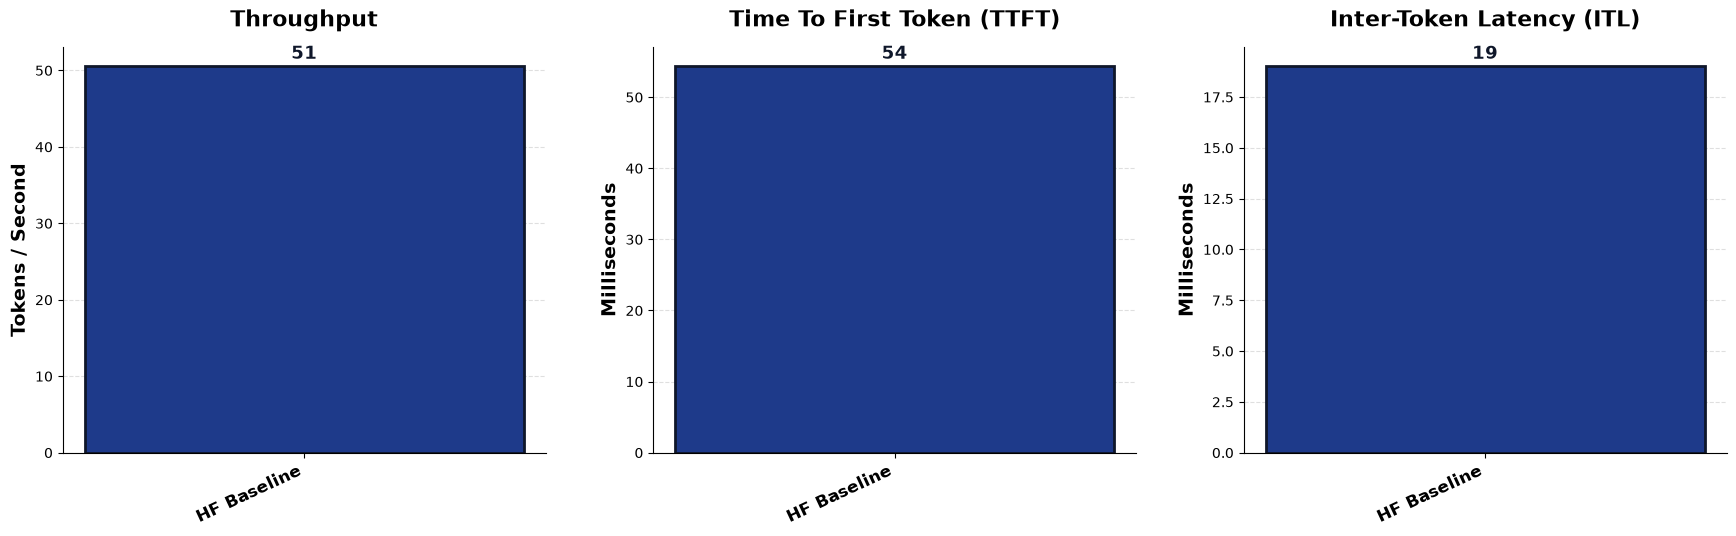

In [4]:
plot_running_comparison()

## 4. vLLM Benchmarks

### --- vLLM Default ---

In [5]:
# --- vLLM Default ---
print("Server Command:\n  python3 -m vllm.entrypoints.openai.api_server --model mistralai/Mistral-7B-v0.1 --port 8000 --max-model-len 4096 --gpu-memory-utilization 0.7")
assert check_server()
warmup_server()
vllm_metrics = benchmark_full(PROMPTS, max_tokens=N_TOKENS, n_workers=N_REQUESTS, label='vLLM')

print('\nKV cache vs concurrent users (max_tokens=1000):')
vllm_kv_users = measure_kv_vs_users()
print('\nKV cache vs context length (up to 3500):')
vllm_kv_context = measure_kv_vs_context()

all_results['vLLM Default'] = {**vllm_metrics, 'kv_users': vllm_kv_users, 'kv_context': vllm_kv_context}
print(f'\nSpeedup over HF: {vllm_metrics["throughput"]/all_results["HF Baseline"]["throughput"]:.1f}x')


Server Command:
  python3 -m vllm.entrypoints.openai.api_server --model mistralai/Mistral-7B-v0.1 --port 8000 --max-model-len 4096 --gpu-memory-utilization 0.7
vLLM server running.


Warmup done (5 requests).


vLLM:   0%|          | 0/10 [00:00<?, ?it/s]

vLLM:  10%|█         | 1/10 [00:00<00:05,  1.58it/s]

vLLM: 100%|██████████| 10/10 [00:00<00:00, 15.46it/s]

...

KV vs context:  80%|████████  | 4/5 [00:14<00:03,  3.71s/it]

   2048 tokens -> 1.3% KV


KV vs context: 100%|██████████| 5/5 [00:18<00:00,  3.71s/it]

KV vs context: 100%|██████████| 5/5 [00:18<00:00,  3.71s/it]

   2500 tokens -> 1.5% KV

Speedup over HF: 14.6x


findfont: Failed to find font weight black, now using 700.


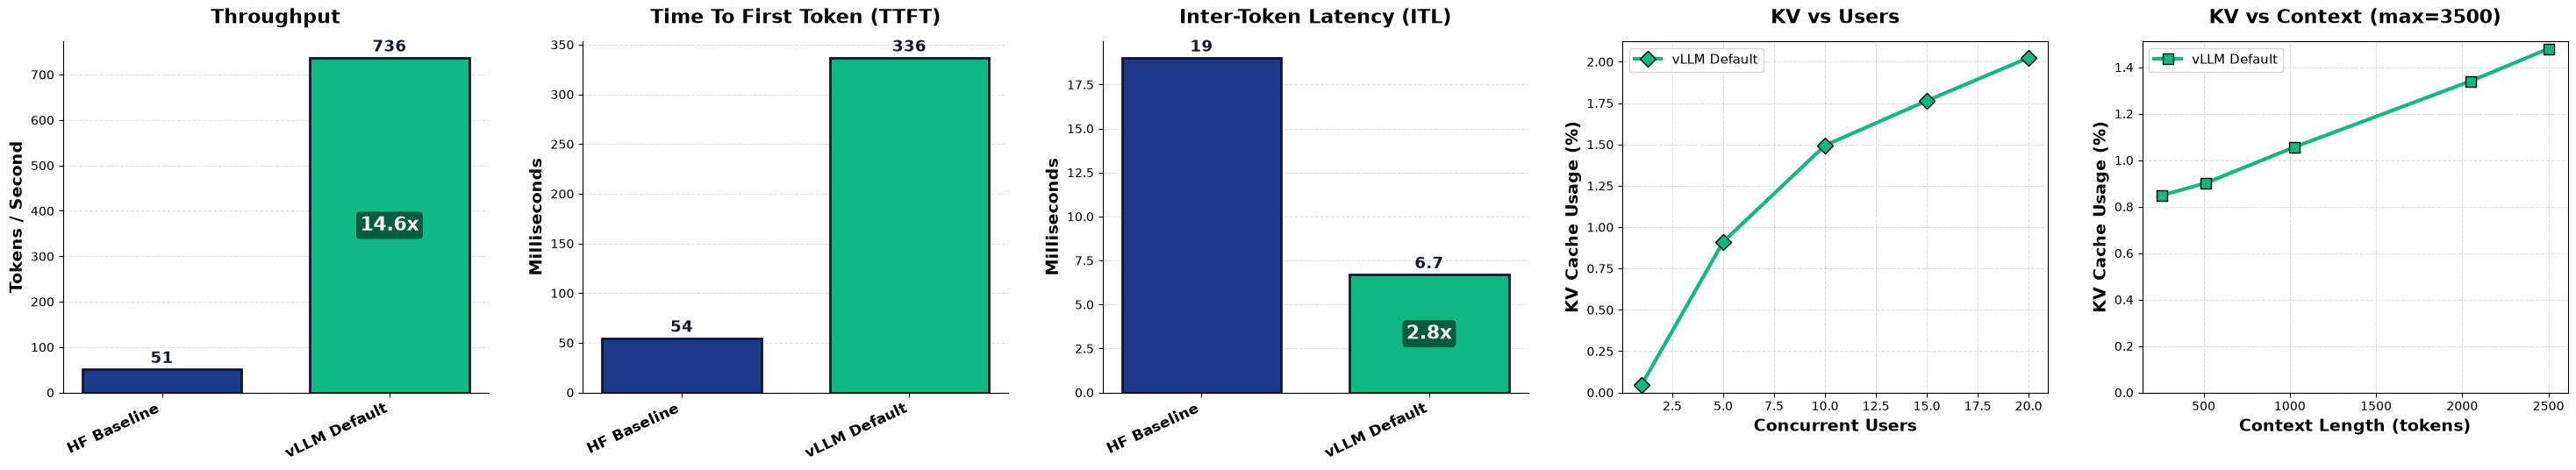

In [6]:
plot_running_comparison()

### --- vLLM + Prefix Caching ---

In [7]:
# --- vLLM + Prefix Caching ---
print("Server Command:\n  python3 -m vllm.entrypoints.openai.api_server --model mistralai/Mistral-7B-v0.1 --port 8000 --max-model-len 4096 --gpu-memory-utilization 0.7 --enable-prefix-caching")
assert check_server()
warmup_server()
prefix_metrics = benchmark_full(PROMPTS, max_tokens=N_TOKENS, n_workers=N_REQUESTS, label='vLLM+Prefix')

print('\nKV cache vs users:')
prefix_kv_users = measure_kv_vs_users()
print('\nKV cache vs context:')
prefix_kv_context = measure_kv_vs_context()

all_results['vLLM Prefix Cache'] = {**prefix_metrics, 'kv_users': prefix_kv_users, 'kv_context': prefix_kv_context}
print(f'\nSpeedup over HF: {prefix_metrics["throughput"]/all_results["HF Baseline"]["throughput"]:.1f}x')


Server Command:
  python3 -m vllm.entrypoints.openai.api_server --model mistralai/Mistral-7B-v0.1 --port 8000 --max-model-len 4096 --gpu-memory-utilization 0.7 --enable-prefix-caching
vLLM server running.


Warmup done (5 requests).


vLLM+Prefix:   0%|          | 0/10 [00:00<?, ?it/s]

vLLM+Prefix:  10%|█         | 1/10 [00:00<00:03,  2.33it/s]

vLLM+Prefix: 100%|██████████| 10/10 [00:00<00:00, 22.64it/s]

...

KV vs context:  80%|████████  | 4/5 [00:14<00:03,  3.71s/it]

   2048 tokens -> 1.3% KV


KV vs context: 100%|██████████| 5/5 [00:18<00:00,  3.71s/it]

KV vs context: 100%|██████████| 5/5 [00:18<00:00,  3.71s/it]

   2500 tokens -> 1.5% KV

Speedup over HF: 20.5x


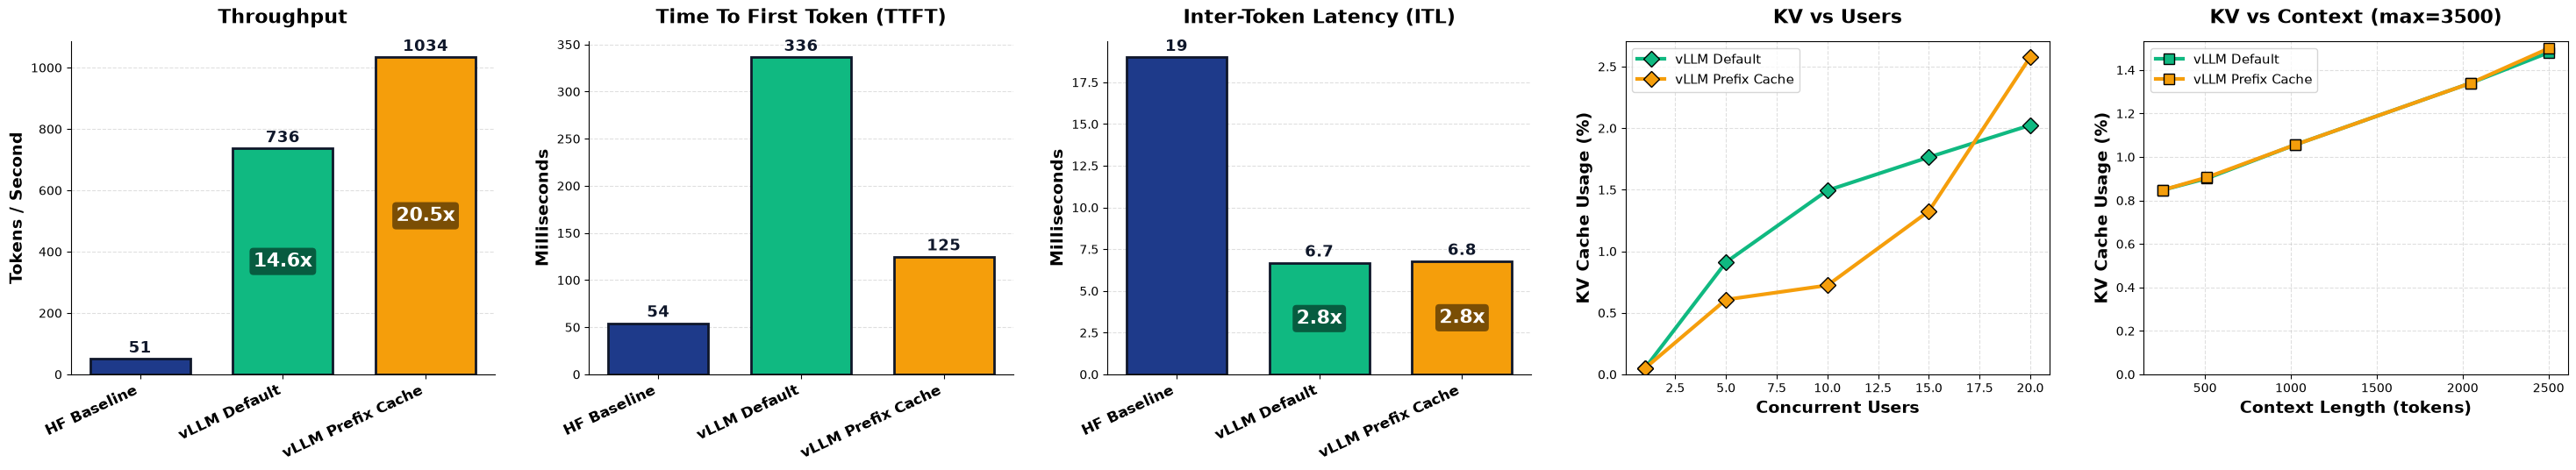

In [8]:
plot_running_comparison()

### --- vLLM + Prefix + KV Quant ---

In [9]:
# --- vLLM + Prefix + KV Quant ---
print("Server Command:\n  python3 -m vllm.entrypoints.openai.api_server --model mistralai/Mistral-7B-v0.1 --port 8000 --max-model-len 4096 --gpu-memory-utilization 0.7 --enable-prefix-caching --kv-cache-dtype fp8")
assert check_server()
warmup_server()
kvq_metrics = benchmark_full(PROMPTS, max_tokens=N_TOKENS, n_workers=N_REQUESTS, label='vLLM+Prefix+KVQ')

print('\nKV cache vs users:')
kvq_kv_users = measure_kv_vs_users()
print('\nKV cache vs context:')
kvq_kv_context = measure_kv_vs_context()

all_results['vLLM Prefix + KV Quant'] = {**kvq_metrics, 'kv_users': kvq_kv_users, 'kv_context': kvq_kv_context}
print(f'\nSpeedup over HF: {kvq_metrics["throughput"]/all_results["HF Baseline"]["throughput"]:.1f}x')


Server Command:
  python3 -m vllm.entrypoints.openai.api_server --model mistralai/Mistral-7B-v0.1 --port 8000 --max-model-len 4096 --gpu-memory-utilization 0.7 --enable-prefix-caching --kv-cache-dtype fp8
vLLM server running.


Warmup done (5 requests).


vLLM+Prefix+KVQ:   0%|          | 0/10 [00:00<?, ?it/s]

vLLM+Prefix+KVQ:  10%|█         | 1/10 [00:00<00:03,  2.26it/s]

vLLM+Prefix+KVQ: 100%|██████████| 10/10 [00:00<00:00, 21.99it/s]

...

KV vs context:  80%|████████  | 4/5 [00:14<00:03,  3.71s/it]

   2048 tokens -> 0.7% KV


KV vs context: 100%|██████████| 5/5 [00:18<00:00,  3.71s/it]

KV vs context: 100%|██████████| 5/5 [00:18<00:00,  3.71s/it]

   2500 tokens -> 0.7% KV

Speedup over HF: 20.0x


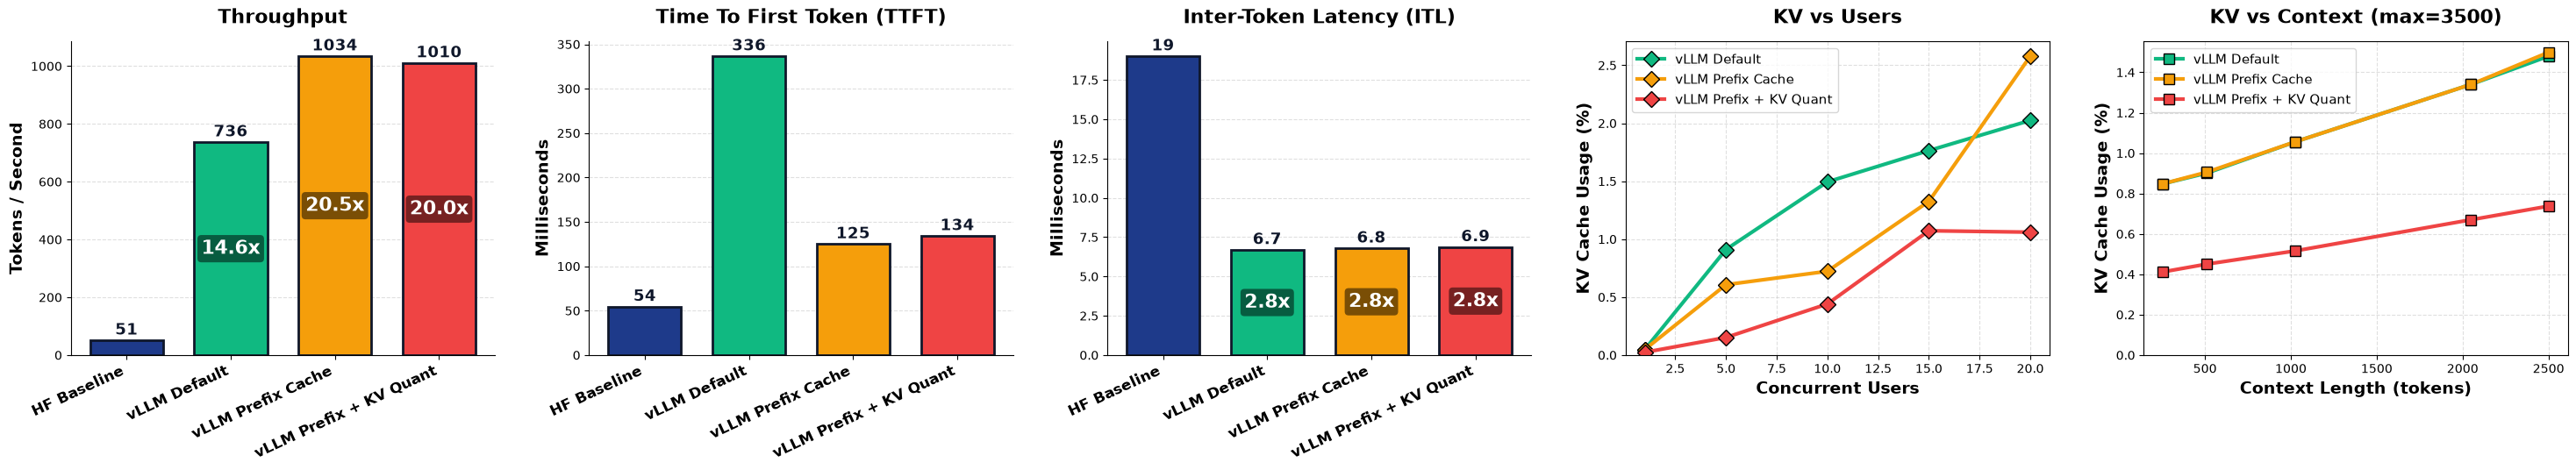

In [10]:
plot_running_comparison()

### --- vLLM + All (Speculative ngram) ---

In [11]:
# --- vLLM + All (Speculative ngram) ---
print("Server Command:\n  python3 -m vllm.entrypoints.openai.api_server --model mistralai/Mistral-7B-v0.1 --port 8000 --max-model-len 4096 --gpu-memory-utilization 0.7 --enable-prefix-caching --kv-cache-dtype fp8 --speculative-config '{\"method\": \"ngram\", \"num_speculative_tokens\": 5}'")
try:
    assert check_server()
    warmup_server()

    spec_metrics = benchmark_full(PROMPTS, max_tokens=N_TOKENS, n_workers=N_REQUESTS, label='vLLM+All')
    
    print('\nKV cache vs users:')
    spec_kv_users = measure_kv_vs_users()
    print('\nKV cache vs context:')
    spec_kv_context = measure_kv_vs_context()

    all_results['vLLM All (Spec ngram)'] = {**spec_metrics, 'kv_users': spec_kv_users, 'kv_context': spec_kv_context}
    print(f'\nSpeedup over HF: {spec_metrics["throughput"]/all_results["HF Baseline"]["throughput"]:.1f}x')
except Exception as e:
    print(f'Speculative failed: {e}')
    all_results['vLLM All (Spec ngram)'] = None


Server Command:
  python3 -m vllm.entrypoints.openai.api_server --model mistralai/Mistral-7B-v0.1 --port 8000 --max-model-len 4096 --gpu-memory-utilization 0.7 --enable-prefix-caching --kv-cache-dtype fp8 --speculative-config '{"method": "ngram", "num_speculative_tokens": 5}'
vLLM server running.


Warmup done (5 requests).


vLLM+All:   0%|          | 0/10 [00:00<?, ?it/s]

vLLM+All:  10%|█         | 1/10 [00:00<00:03,  2.27it/s]

vLLM+All: 100%|██████████| 10/10 [00:00<00:00, 21.71it/s]

...

KV vs context:  80%|████████  | 4/5 [00:14<00:03,  3.71s/it]

   2048 tokens -> 0.6% KV


KV vs context: 100%|██████████| 5/5 [00:18<00:00,  3.71s/it]

KV vs context: 100%|██████████| 5/5 [00:18<00:00,  3.71s/it]

   2500 tokens -> 0.6% KV

Speedup over HF: 19.6x


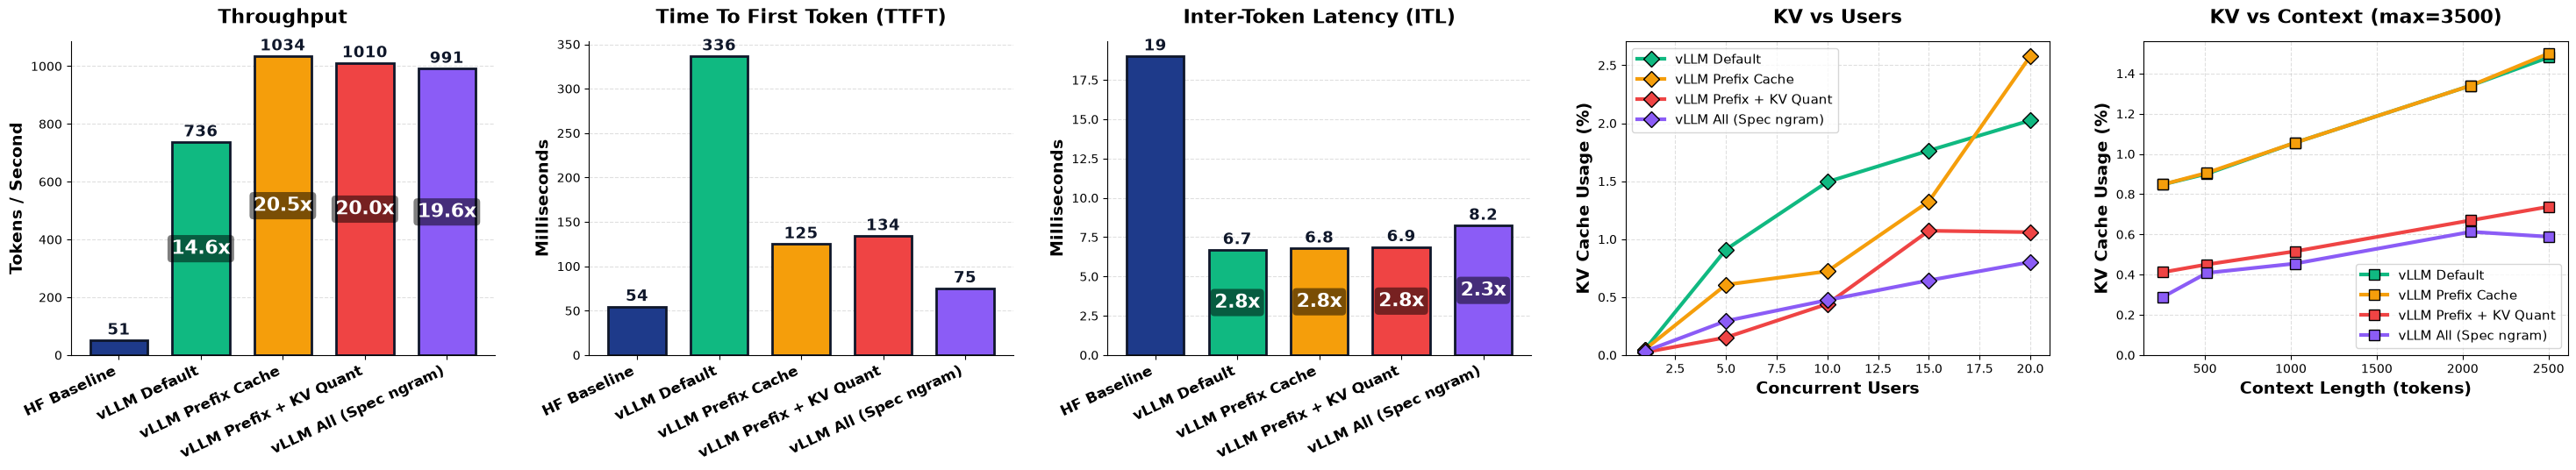

In [12]:
plot_running_comparison()

## 5. Final Multi-Panel Comparison

/tmp/ipykernel_20525/4272522092.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(configs, rotation=25, ha='right', fontsize=11, fontweight='bold')
findfont: Failed to find font weight heavy, now using 700.


findfont: Failed to find font weight black, now using 700.


findfont: Failed to find font weight black, now using 700.


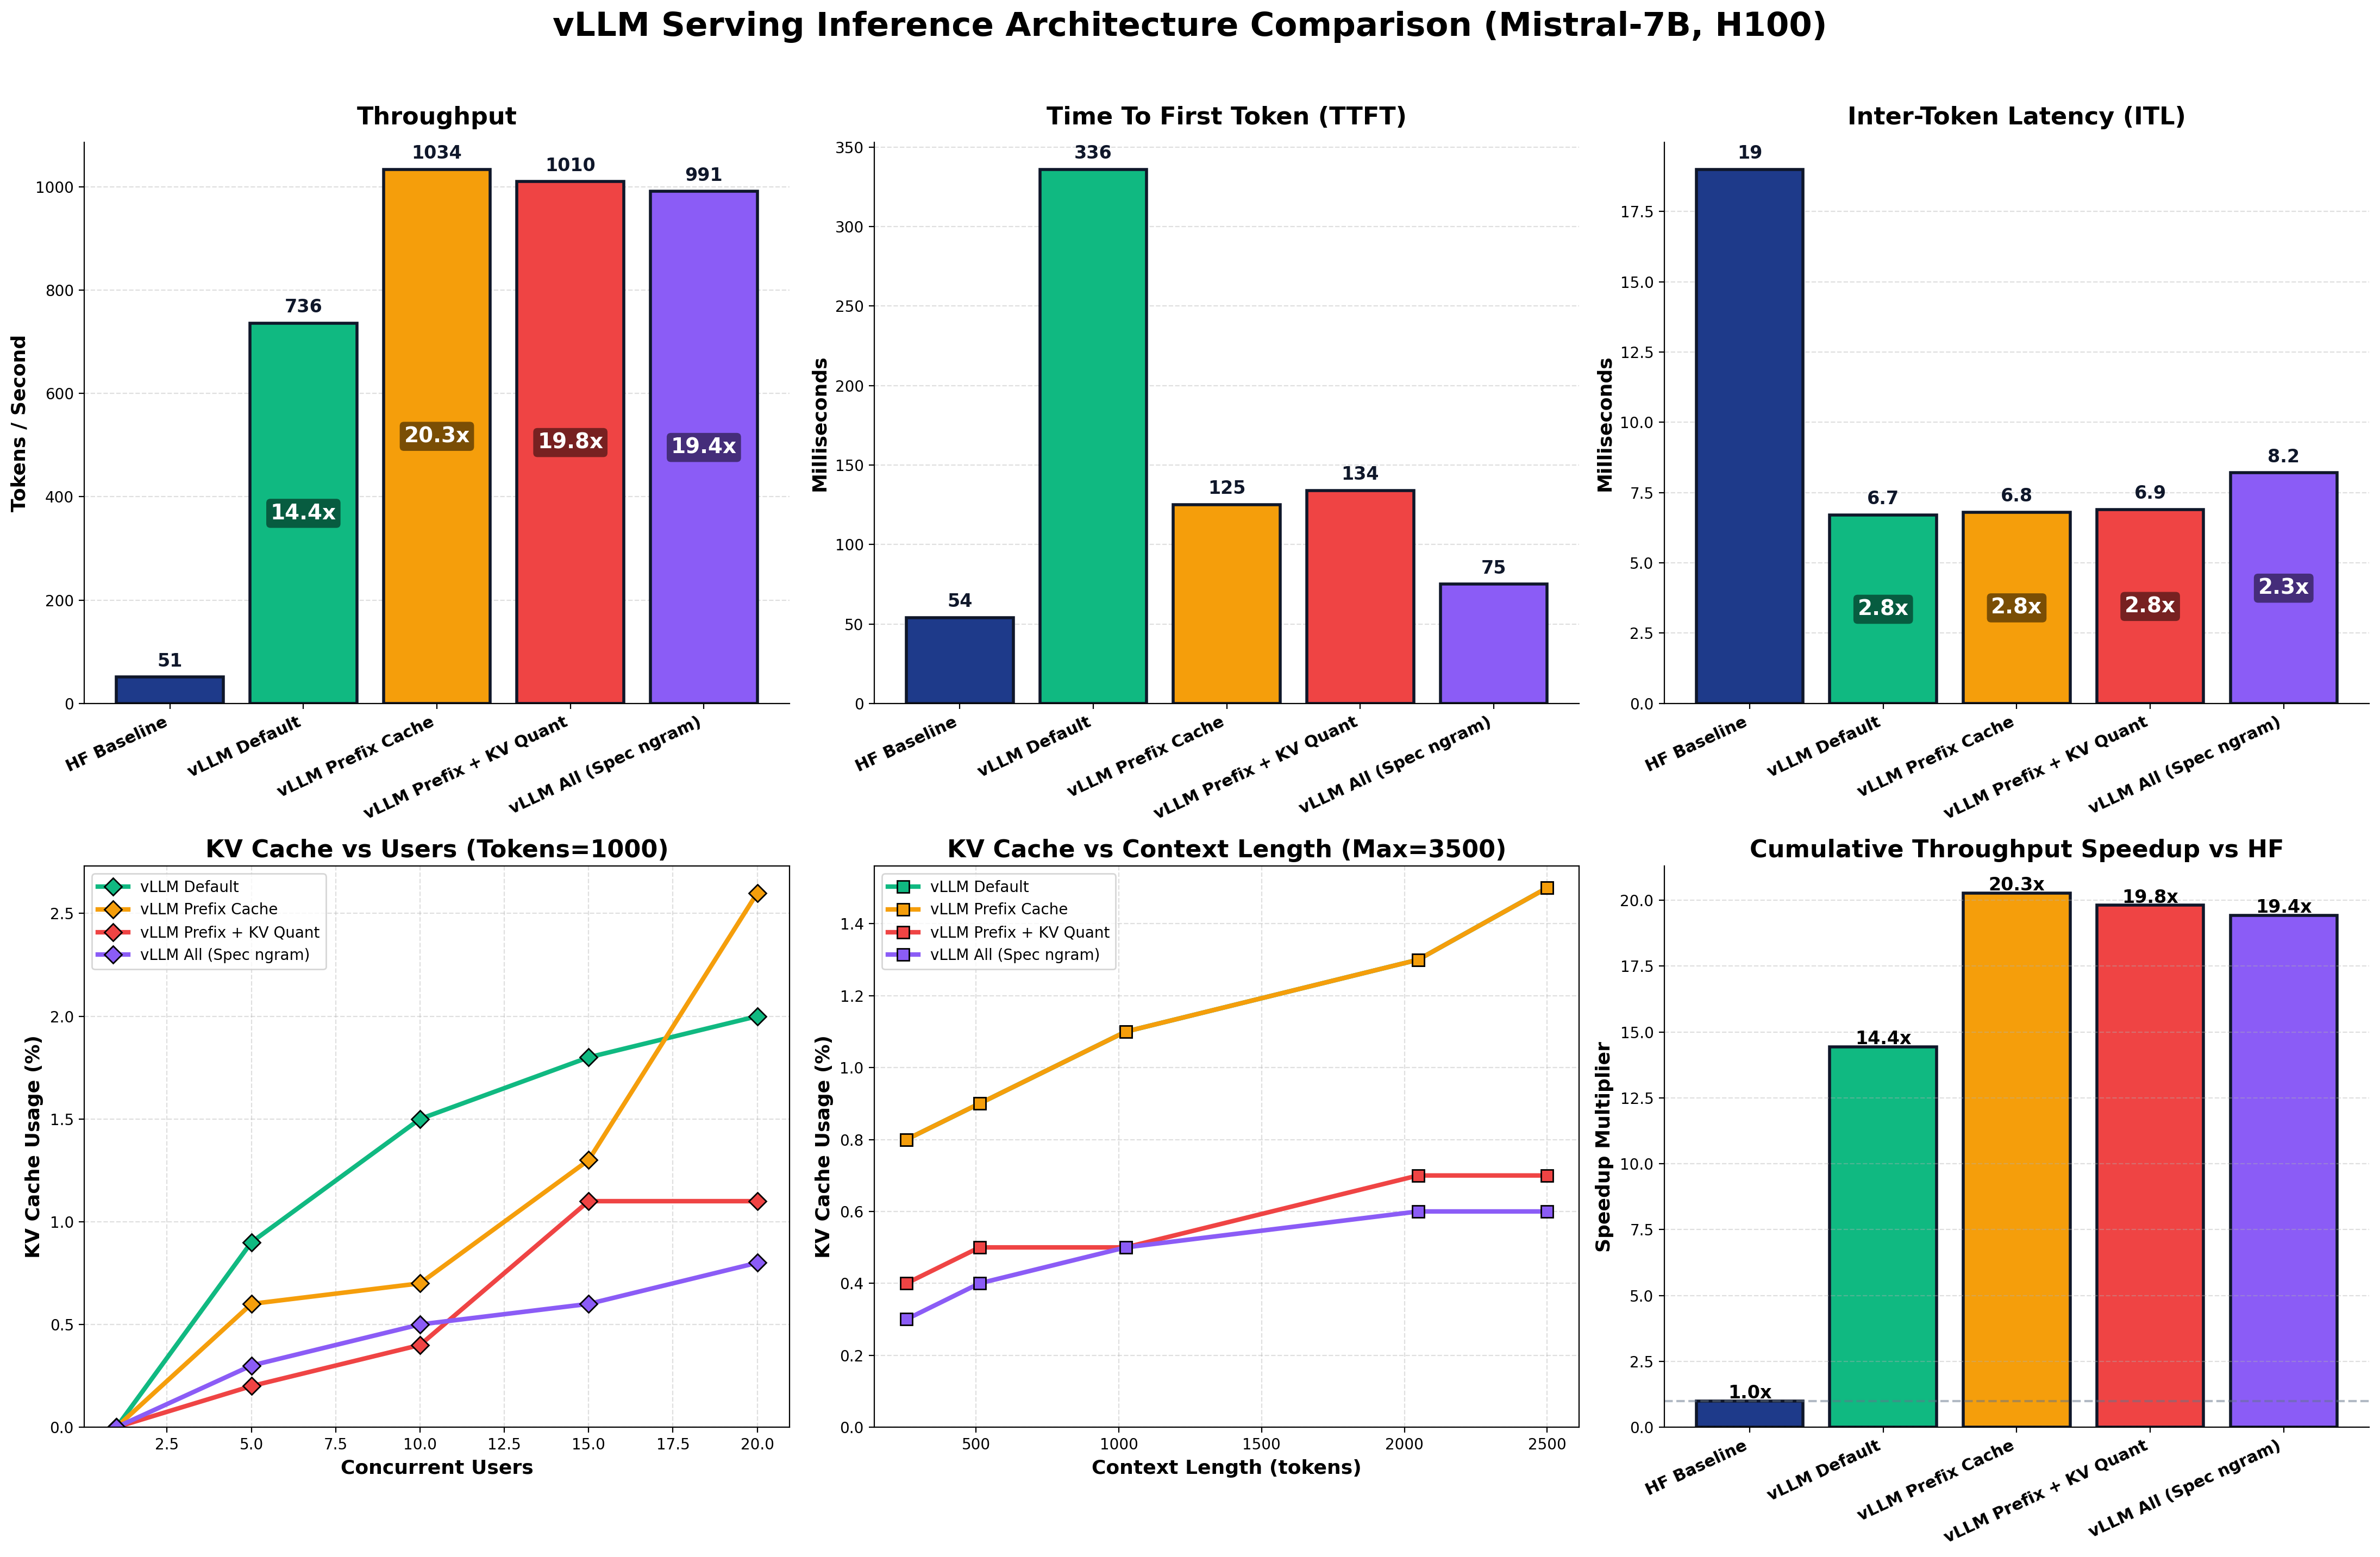


Config                       tok/s   TTFT ms    ITL ms     vs HF
---------------------------------------------------------------------------
HF Baseline                     51        54      19.0      1.0x
vLLM Default                   736       336       6.7     14.6x
vLLM Prefix Cache             1034       125       6.8     20.5x
vLLM Prefix + KV Quant        1010       134       6.9     20.0x
vLLM All (Spec ngram)          991        75       8.2     19.6x


In [13]:
valid = {k: v for k, v in all_results.items() if v is not None}
configs = list(valid.keys())
bar_colors = ['#1e3a8a', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6'][:len(configs)]

fig, axes = plt.subplots(2, 3, figsize=(22, 14))

def style_final_ax(ax, title, ylabel, values, is_lower_better=False):
    x = np.arange(len(configs))
    bars = ax.bar(x, values, color=bar_colors, edgecolor='#0f172a', linewidth=2)
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=25, ha='right', fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='heavy', pad=12)
    ax.grid(axis='y', alpha=0.4, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    
    for bar, val in zip(bars, values):
        label = f'{val:.0f}' if val >= 10 else f'{val:.1f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(values)*0.02),
               label, ha='center', fontsize=12, fontweight='heavy', color='#0f172a')
               
    if len(values) > 1 and values[0] > 0:
        for i in range(1, len(values)):
            ratio = values[0]/values[i] if is_lower_better else values[i]/values[0]
            if ratio > 1.2:
                ax.text(i, values[i] * 0.5, f'{ratio:.1f}x', ha='center', va='center', 
                        fontsize=14, color='white', fontweight='black',
                        bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2', edgecolor='none'))

# --- Row 1: Throughput, TTFT, ITL ---
tps = [valid[c]['throughput'] for c in configs]
style_final_ax(axes[0, 0], 'Throughput', 'Tokens / Second', tps)

ttfts = [valid[c]['ttft'] * 1000 for c in configs]
style_final_ax(axes[0, 1], 'Time To First Token (TTFT)', 'Milliseconds', ttfts, is_lower_better=True)

itls = [valid[c]['itl'] * 1000 for c in configs]
style_final_ax(axes[0, 2], 'Inter-Token Latency (ITL)', 'Milliseconds', itls, is_lower_better=True)

# --- Row 2: KV cache growth charts ---
ax = axes[1, 0]
for i, c in enumerate(configs):
    kv = valid[c].get('kv_users')
    if kv:
        ax.plot([x[0] for x in kv], [x[1] for x in kv], 'D-', color=bar_colors[i], markeredgecolor='black', linewidth=3, markersize=8, label=c)
ax.set_xlabel('Concurrent Users', fontsize=13, fontweight='bold')
ax.set_ylabel('KV Cache Usage (%)', fontsize=13, fontweight='bold')
ax.set_title('KV Cache vs Users (Tokens=1000)', fontsize=16, fontweight='heavy')
ax.set_ylim(bottom=0)
ax.grid(alpha=0.4, linestyle='--')
ax.legend(fontsize=10)

ax = axes[1, 1]
for i, c in enumerate(configs):
    kv = valid[c].get('kv_context')
    if kv:
        ax.plot([x[0] for x in kv], [x[1] for x in kv], 's-', color=bar_colors[i], markeredgecolor='black', linewidth=3, markersize=8, label=c)
ax.set_xlabel('Context Length (tokens)', fontsize=13, fontweight='bold')
ax.set_ylabel('KV Cache Usage (%)', fontsize=13, fontweight='bold')
ax.set_title('KV Cache vs Context Length (Max=3500)', fontsize=16, fontweight='heavy')
ax.set_ylim(bottom=0)
ax.grid(alpha=0.4, linestyle='--')
ax.legend(fontsize=10)

# Speedup summary
ax = axes[1, 2]
hf_tps = valid['HF Baseline']['throughput']
speedups = [valid[c]['throughput'] / hf_tps for c in configs]
bars = ax.bar(configs, speedups, color=bar_colors, edgecolor='#0f172a', linewidth=2)
for bar, val in zip(bars, speedups):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.1f}x', ha='center', fontsize=12, fontweight='heavy')
ax.set_ylabel('Speedup Multiplier', fontsize=13, fontweight='bold')
ax.set_title('Cumulative Throughput Speedup vs HF', fontsize=16, fontweight='heavy')
ax.set_xticklabels(configs, rotation=25, ha='right', fontsize=11, fontweight='bold')
ax.axhline(y=1, color='#64748b', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('vLLM Serving Inference Architecture Comparison (Mistral-7B, H100)', fontsize=22, fontweight='black', y=1.02)
plt.tight_layout()
plt.savefig('demo_f_full_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# Print table
print('\n' + '='*75)
print(f'{"Config":<25} {"tok/s":>8} {"TTFT ms":>9} {"ITL ms":>9} {"vs HF":>9}')
print('-'*75)
for c in configs:
    r = valid[c]
    print(f"{c:<25} {r['throughput']:>8.0f} {r['ttft']*1000:>9.0f} {r['itl']*1000:>9.1f} {r['throughput']/hf_tps:>8.1f}x")
print('='*75)
